In [5]:
from google.colab import files
uploaded = files.upload()

Saving delhi-weather-aqi-2025 (1).csv to delhi-weather-aqi-2025 (1) (1).csv


In [8]:
import pandas as pd

df = pd.read_csv('delhi-weather-aqi-2025 (1) (1).csv')
print(df.shape)
df.head()

(52560, 16)


,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


Positive correlation (PM10 vs AQI)            : 0.831
Negative correlation (Temperature vs Pressure): -0.717
No correlation (Humidity vs Pressure)         : -0.012


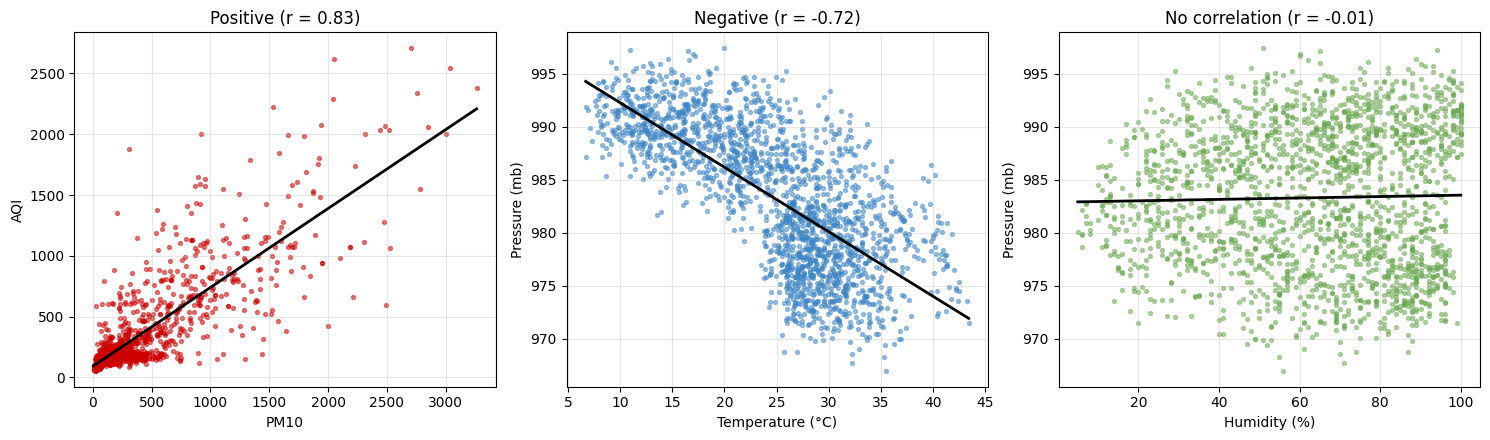


Check with built-in .corr(): 0.831 -0.717 -0.012


In [10]:
import math
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('delhi-weather-aqi-2025 (1) (1).csv')

def correlation(x, y):
    n = len(x)
    mean_x = sum(x) / n
    mean_y = sum(y) / n

    top = 0
    sq_x = 0
    sq_y = 0
    for i in range(n):
        dx = x[i] - mean_x
        dy = y[i] - mean_y
        top += dx * dy
        sq_x += dx ** 2
        sq_y += dy ** 2

    return top / math.sqrt(sq_x * sq_y)

pos_x, pos_y = df['pm10'].tolist(),     df['aqi_index'].tolist()
neg_x, neg_y = df['temp_c'].tolist(),   df['pressure_mb'].tolist()
no_x,  no_y  = df['humidity'].tolist(), df['pressure_mb'].tolist()

r_pos = correlation(pos_x, pos_y)
r_neg = correlation(neg_x, neg_y)
r_no  = correlation(no_x, no_y)


print("Positive correlation (PM10 vs AQI)            :", round(r_pos, 3))
print("Negative correlation (Temperature vs Pressure):", round(r_neg, 3))
print("No correlation (Humidity vs Pressure)         :", round(r_no, 3))

s = df.sample(2000, random_state=1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

def draw(a, x, y, color, title, xl, yl):
    a.scatter(s[x], s[y], s=8, alpha=0.5, color=color)
    mx, my = s[x].mean(), s[y].mean()
    slope = ((s[x]-mx)*(s[y]-my)).sum() / ((s[x]-mx)**2).sum()
    xs = [s[x].min(), s[x].max()]
    a.plot(xs, [my + slope*(v-mx) for v in xs], color='black', linewidth=2)
    a.set_title(title); a.set_xlabel(xl); a.set_ylabel(yl); a.grid(alpha=0.3)

draw(ax[0], 'pm10', 'aqi_index', '#CC0000', f'Positive (r = {r_pos:.2f})', 'PM10', 'AQI')
draw(ax[1], 'temp_c', 'pressure_mb', '#3D85C6', f'Negative (r = {r_neg:.2f})', 'Temperature (°C)', 'Pressure (mb)')
draw(ax[2], 'humidity', 'pressure_mb', '#6AA84F', f'No correlation (r = {r_no:.2f})', 'Humidity (%)', 'Pressure (mb)')
plt.tight_layout()
plt.show()

print("\nCheck with built-in .corr():",
      round(df['pm10'].corr(df['aqi_index']), 3),
      round(df['temp_c'].corr(df['pressure_mb']), 3),
      round(df['humidity'].corr(df['pressure_mb']), 3))